# 🚗 Car Specifications Analysis using Python

## Module 1 – Understanding the Need for Principal Component Analysis (PCA)

**Author:** Keshavarthini S

**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn

**Objective:**
To analyze relationships between car features and understand why Principal Component Analysis (PCA) is useful before applying Machine Learning.

# 📌 Introduction

Modern car datasets contain many numerical features such as engine size, horsepower, weight, mileage, and price. Many of these features are highly correlated.

This notebook performs Exploratory Data Analysis (EDA) and Correlation Analysis to identify redundant features and understand whether PCA is needed.

# 🎯 Project Objectives

- Understand the dataset
- Perform data cleaning
- Explore the dataset
- Generate descriptive statistics
- Analyze feature relationships
- Visualize feature correlations
- Explain why PCA is required

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [8]:
import pandas as pd


df = pd.read_excel(r"C:\Users\Kesha\Documents\car data analysis\dataset\car_dataset.xlsx")

df.head()

df.head()

,Car_ID,Brand,Model,Year,Engine_Size_L,Horsepower,Weight_kg,Mileage_kmpl,Price_USD,Fuel_Type,Transmission
0,1,Audi,E,2017,3.9,270,2085,17.1,78579,Petrol,Manual
1,2,Toyota,D,2018,2.0,148,1474,24.0,47114,Petrol,Automatic
2,3,Honda,E,2018,1.5,147,1412,24.0,41113,Petrol,Automatic
3,4,Tata,B,2021,3.1,224,1914,21.8,61174,Diesel,Manual
4,5,Audi,A,2019,1.6,136,1310,24.1,42256,Hybrid,Automatic


# 8. Descriptive Statistics

Descriptive statistics provide a summary of the numerical features in the dataset. It helps us understand the central tendency, spread, minimum and maximum values, and overall distribution of the data before performing further analysis.

In [9]:
# Descriptive Statistics
df.describe()

,Car_ID,Year,Engine_Size_L,Horsepower,Weight_kg,Mileage_kmpl,Price_USD
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,500.500000,2020.110000,2.998500,234.639000,1871.279000,20.968500,63177.39700
std,288.819436,3.065501,1.168123,69.910816,414.724805,3.708273,18750.86837
min,1.000000,2015.000000,1.000000,75.000000,1075.000000,13.400000,23147.00000
25%,250.750000,2017.000000,2.000000,181.000000,1499.000000,17.900000,47481.75000
50%,500.500000,2020.000000,3.000000,237.000000,1866.000000,21.100000,62881.50000
75%,750.250000,2023.000000,4.000000,289.000000,2229.500000,24.200000,79006.75000
max,1000.000000,2025.000000,5.000000,388.000000,2651.000000,28.300000,104222.00000


In [10]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

df.describe()

,Car_ID,Year,Engine_Size_L,Horsepower,Weight_kg,Mileage_kmpl,Price_USD
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,500.500000,2020.110000,2.998500,234.639000,1871.279000,20.968500,63177.39700
std,288.819436,3.065501,1.168123,69.910816,414.724805,3.708273,18750.86837
min,1.000000,2015.000000,1.000000,75.000000,1075.000000,13.400000,23147.00000
25%,250.750000,2017.000000,2.000000,181.000000,1499.000000,17.900000,47481.75000
50%,500.500000,2020.000000,3.000000,237.000000,1866.000000,21.100000,62881.50000
75%,750.250000,2023.000000,4.000000,289.000000,2229.500000,24.200000,79006.75000
max,1000.000000,2025.000000,5.000000,388.000000,2651.000000,28.300000,104222.00000


In [11]:
numeric_df = df.select_dtypes(include=['number'])

numeric_df.describe()

,Car_ID,Year,Engine_Size_L,Horsepower,Weight_kg,Mileage_kmpl,Price_USD
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,500.500000,2020.110000,2.998500,234.639000,1871.279000,20.968500,63177.39700
std,288.819436,3.065501,1.168123,69.910816,414.724805,3.708273,18750.86837
min,1.000000,2015.000000,1.000000,75.000000,1075.000000,13.400000,23147.00000
25%,250.750000,2017.000000,2.000000,181.000000,1499.000000,17.900000,47481.75000
50%,500.500000,2020.000000,3.000000,237.000000,1866.000000,21.100000,62881.50000
75%,750.250000,2023.000000,4.000000,289.000000,2229.500000,24.200000,79006.75000
max,1000.000000,2025.000000,5.000000,388.000000,2651.000000,28.300000,104222.00000


## Observations

- The dataset contains multiple numerical features.
- Features such as Horsepower, Engine Size, Weight, and Price have different ranges.
- These differences indicate that feature scaling will be necessary before applying PCA.
- The descriptive statistics provide a good understanding of the dataset's overall distribution.

# 9. Correlation Analysis

Correlation analysis helps us understand the relationship between numerical features in the dataset.

The correlation coefficient ranges from **-1 to +1**:

- **+1** → Perfect Positive Correlation
- **0** → No Correlation
- **-1** → Perfect Negative Correlation

Understanding these relationships helps identify redundant features, which is one of the main reasons for using Principal Component Analysis (PCA).

In [12]:
# Calculate Correlation Matrix

correlation = numeric_df.corr()

correlation

,Car_ID,Year,Engine_Size_L,Horsepower,Weight_kg,Mileage_kmpl,Price_USD
Car_ID,1.000000,0.057305,0.009025,0.011620,0.009704,-0.005042,0.010674
Year,0.057305,1.000000,-0.034980,-0.025158,-0.035783,0.039860,-0.027150
Engine_Size_L,0.009025,-0.034980,1.000000,0.906455,0.990140,-0.950815,0.971717
Horsepower,0.011620,-0.025158,0.906455,1.000000,0.893673,-0.864816,0.956255
Weight_kg,0.009704,-0.035783,0.990140,0.893673,1.000000,-0.942440,0.959540
Mileage_kmpl,-0.005042,0.039860,-0.950815,-0.864816,-0.942440,1.000000,-0.924258
Price_USD,0.010674,-0.027150,0.971717,0.956255,0.959540,-0.924258,1.000000


In [13]:
threshold = 0.80

corr_matrix = correlation.abs()

print("Highly Correlated Features\n")

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > threshold:
            print(
                f"{corr_matrix.columns[i]} <--> {corr_matrix.columns[j]} : {corr_matrix.iloc[i, j]:.2f}"
            )

Highly Correlated Features

Horsepower <--> Engine_Size_L : 0.91
Weight_kg <--> Engine_Size_L : 0.99
Weight_kg <--> Horsepower : 0.89
Mileage_kmpl <--> Engine_Size_L : 0.95
Mileage_kmpl <--> Horsepower : 0.86
Mileage_kmpl <--> Weight_kg : 0.94
Price_USD <--> Engine_Size_L : 0.97
Price_USD <--> Horsepower : 0.96
Price_USD <--> Weight_kg : 0.96
Price_USD <--> Mileage_kmpl : 0.92


## Observations

- Several numerical features show strong positive correlations.
- Features such as Engine Size and Horsepower are expected to be highly correlated.
- Some features provide similar information, leading to redundancy.
- Highly correlated features indicate that dimensionality reduction techniques like PCA may be useful.

# 10. Correlation Heatmap

A correlation heatmap is a visual representation of the correlation matrix.

It helps us quickly identify:
- Strong positive correlations
- Strong negative correlations
- Weak correlations
- Redundant features

This visualization makes it easier to determine whether dimensionality reduction techniques like PCA are required.

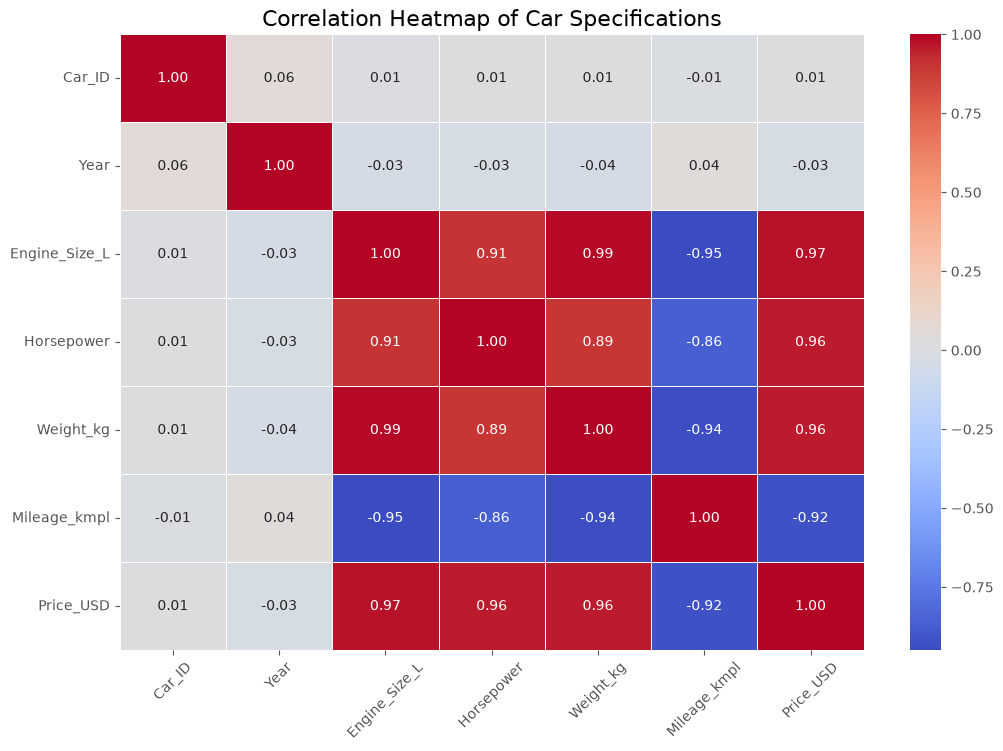

In [14]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Car Specifications", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

## Observations

- Dark red colors indicate strong positive correlations.
- Dark blue colors indicate strong negative correlations.
- Light-colored cells indicate weak or no correlation.
- Multiple highly correlated features suggest redundancy in the dataset.
- PCA can help combine these correlated features into a smaller set of principal components.

# 11. Feature Relationship Analysis

In this section, we explore the relationships between important numerical features using scatter plots.

Scatter plots help us understand whether two variables have a positive, negative, or no relationship.

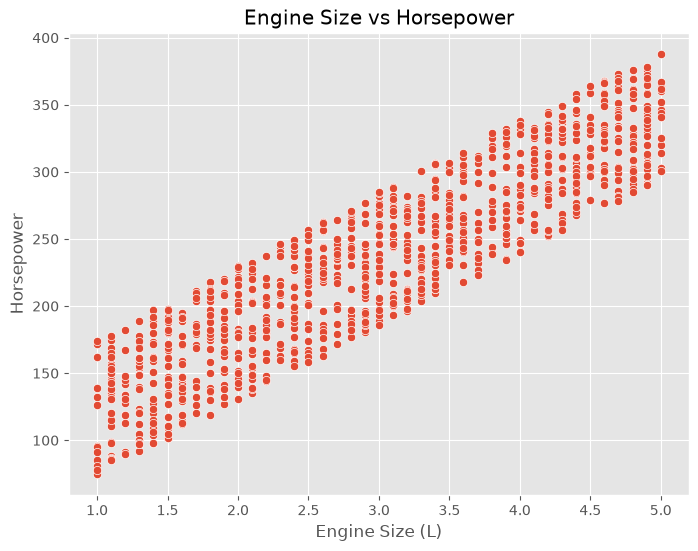

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Engine_Size_L",
    y="Horsepower"
)

plt.title("Engine Size vs Horsepower")
plt.xlabel("Engine Size (L)")
plt.ylabel("Horsepower")

plt.show()

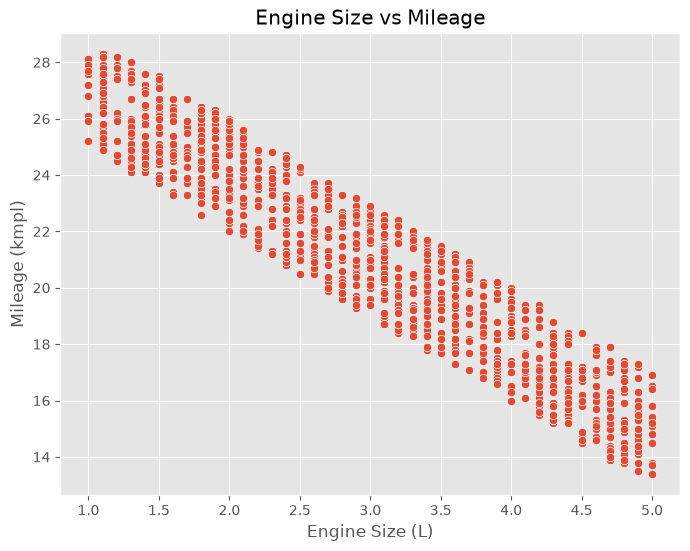

In [16]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Engine_Size_L",
    y="Mileage_kmpl"
)

plt.title("Engine Size vs Mileage")
plt.xlabel("Engine Size (L)")
plt.ylabel("Mileage (kmpl)")

plt.show()

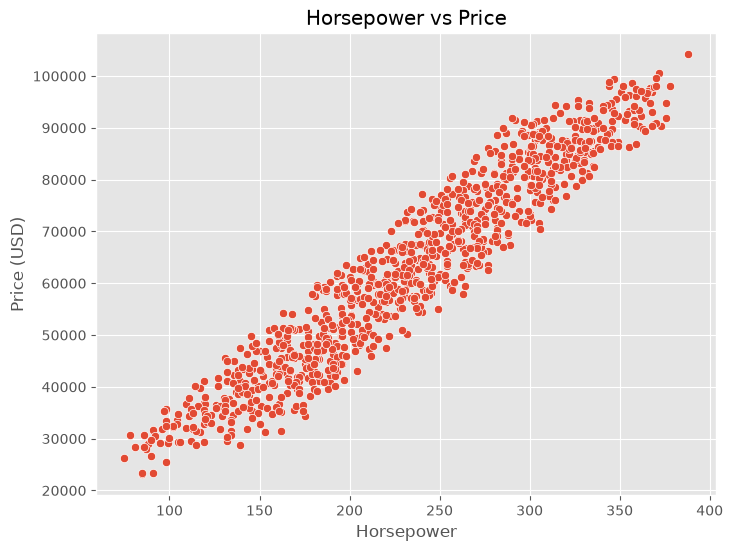

In [17]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Horsepower",
    y="Price_USD"
)

plt.title("Horsepower vs Price")
plt.xlabel("Horsepower")
plt.ylabel("Price (USD)")

plt.show()

## Observations

- Larger engine sizes generally produce higher horsepower.
- As engine size increases, fuel efficiency (mileage) tends to decrease.
- Cars with higher horsepower usually have higher prices.
- These relationships confirm that some features are strongly connected and may contain overlapping information.

# 12. Business Insights

Based on the exploratory data analysis and correlation analysis, the following business insights were identified.

## Business Insights

### 1. Engine Size and Horsepower
Cars with larger engine sizes generally produce more horsepower, indicating a strong positive relationship.

### 2. Engine Size and Mileage
As engine size increases, fuel efficiency tends to decrease. Larger engines consume more fuel.

### 3. Horsepower and Price
Vehicles with higher horsepower generally have higher market prices.

### 4. Weight and Performance
Heavier vehicles are often associated with larger engines and increased horsepower.

### 5. Redundant Features
Several numerical features are highly correlated and may contain overlapping information.

These observations indicate that dimensionality reduction techniques such as PCA can simplify the dataset while preserving most of its important information.

# 13. Why PCA is Needed?

Principal Component Analysis (PCA) is a dimensionality reduction technique used to transform highly correlated features into a smaller set of uncorrelated principal components.

### Why PCA may be useful for this dataset:

- Several numerical features are highly correlated.
- Redundant information increases computational complexity.
- High-dimensional data can make machine learning models slower.
- PCA helps preserve important information while reducing the number of features.
- Reduced dimensions improve visualization and model efficiency.

In this module, PCA has **not** been applied. The analysis performed here helps determine whether PCA is appropriate for the dataset.

# 14. Conclusion

This project explored the relationships between various car specifications through Exploratory Data Analysis (EDA) and Correlation Analysis.

### Key Findings

- The dataset contains several numerical features with strong correlations.
- Engine Size, Horsepower, Weight, and Price exhibit meaningful relationships.
- Correlation analysis revealed redundant information among certain features.
- PCA is a suitable technique for reducing dimensionality in this dataset.

### Learning Outcomes

- Loaded and explored a real-world dataset.
- Performed data cleaning.
- Generated descriptive statistics.
- Conducted correlation analysis.
- Visualized feature relationships.
- Understood the importance of PCA before implementation.

This completes **Module 1: Understanding the Need for PCA**.

The next module will focus on the mathematical foundations of PCA, including:
- Mean
- Variance
- Standard Deviation
- Covariance
- Correlation

# Thank You

Thank you for exploring this project.

If you found this notebook useful, feel free to connect with me on LinkedIn and explore more of my data analytics projects on GitHub.

**Author:** Keshavarthini S

Learning one concept at a time, building practical skills through real-world projects.